In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Phase 3 — Augmentation and Custom CNN

This notebook builds the augmentation pipeline, defines and trains a custom CNN, saves model artifacts, plots learning curves, and writes short model notes for the aerial object classification task.

## 1. Imports and environment setup

This cell imports project utilities, loads configs, sets reproducibility, and prepares the main project paths for the custom CNN experiment.

In [15]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf

PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import load_yaml
from src.utils.logger import get_logger
from src.utils.seed import set_seed
from src.utils.paths import load_paths_config
from src.data.classification_loader import scan_classification_dataset
from src.data.dataset_audit import get_sample_images
from src.features.augmentations import (
    build_train_augmentation_pipeline,
    save_augmentation_preview,
)
from src.modeling.train_classifier import train_custom_cnn_pipeline

## 2. Load configuration files

This cell loads `paths.yaml` and `classification_config.yaml`, extracts the custom CNN configuration, and resolves the processed classification dataset location.

In [16]:
logger = get_logger(name="phase3_custom_cnn")

paths_config = load_paths_config(PROJECT_ROOT / "configs" / "paths.yaml")
classification_config = load_yaml(PROJECT_ROOT / "configs" / "classification_config.yaml")
custom_cnn_config = classification_config["custom_cnn"]

processed_classification_root = paths_config.get(
    "processed_classification_root",
    paths_config["processed_root"] / "classification"
)

report_path = PROJECT_ROOT / custom_cnn_config["artifacts"]["report_path"]
augmentation_preview_path = PROJECT_ROOT / custom_cnn_config["artifacts"]["augmentation_preview_path"]
accuracy_curve_path = PROJECT_ROOT / custom_cnn_config["artifacts"]["accuracy_curve_path"]
loss_curve_path = PROJECT_ROOT / custom_cnn_config["artifacts"]["loss_curve_path"]

set_seed(custom_cnn_config["training"]["seed"])

print("Processed classification root:", processed_classification_root)
print("Report path:", report_path)
print("Augmentation preview path:", augmentation_preview_path)
print("Accuracy curve path:", accuracy_curve_path)
print("Loss curve path:", loss_curve_path)

Processed classification root: /content/drive/MyDrive/Aerial_Object_Classification_Detection/data/processed/classification
Report path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/reports/custom_cnn_report.md
Augmentation preview path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/preprocessing/augmentation_preview.png
Accuracy curve path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/training/custom_cnn_accuracy.png
Loss curve path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/training/custom_cnn_loss.png


## 3. Validate processed classification dataset

This cell checks the split/class folder structure that was created in the earlier preprocessing phase and prints the image counts per split and class.

In [17]:
scan_df = scan_classification_dataset(
    dataset_root=processed_classification_root,
    expected_splits=classification_config["dataset"]["expected_splits"],
    expected_classes=classification_config["dataset"]["expected_classes"],
    allowed_extensions=classification_config["dataset"]["allowed_extensions"],
)

display(scan_df)

pivot_counts = scan_df.pivot(index="split", columns="class_name", values="image_count")
display(pivot_counts)

,split,class_name,image_count,class_dir_exists
0,train,bird,1414,True
1,train,drone,1248,True
2,valid,bird,217,True
3,valid,drone,225,True
4,test,bird,121,True
5,test,drone,94,True


class_name,bird,drone
split,,
test,121,94
train,1414,1248
valid,217,225


## 4. Build augmentation pipeline

This cell creates the TensorFlow/Keras augmentation pipeline used only for the training set. It includes rotation, horizontal flip, optional vertical flip, zoom, brightness variation, and translation-based shift.

In [18]:
augmentation_model = build_train_augmentation_pipeline(
    image_size=custom_cnn_config["training"]["image_size"],
    rotation_factor=custom_cnn_config["augmentation"]["rotation_factor"],
    horizontal_flip=custom_cnn_config["augmentation"]["horizontal_flip"],
    vertical_flip=custom_cnn_config["augmentation"]["vertical_flip"],
    zoom_factor=custom_cnn_config["augmentation"]["zoom_factor"],
    brightness_factor=custom_cnn_config["augmentation"]["brightness_factor"],
    translation_height_factor=custom_cnn_config["augmentation"]["translation_height_factor"],
    translation_width_factor=custom_cnn_config["augmentation"]["translation_width_factor"],
)

augmentation_model

<Sequential name=train_augmentation_pipeline, built=False>

## 5. Save augmentation preview

This cell samples a few training images and saves a side-by-side original vs augmented preview figure to `figures/preprocessing/augmentation_preview.png`.

In [21]:
sample_class_dir = processed_classification_root / "train" / classification_config["dataset"]["expected_classes"][0]
sample_images = get_sample_images(
    class_dir=sample_class_dir,
    n_samples=4,
    seed=classification_config["audit"]["random_seed"],
)

save_augmentation_preview(
    image_paths=sample_images,
    augmentation_model=augmentation_model,
    output_path=augmentation_preview_path,
    image_size=tuple(custom_cnn_config["training"]["image_size"]),
    n_samples=4,
    dpi=classification_config["visualization"]["dpi"],
)

print("Saved augmentation preview to:", augmentation_preview_path)

Saved augmentation preview to: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/preprocessing/augmentation_preview.png


## 6. Train the custom CNN

This cell launches the end-to-end training pipeline. It builds TensorFlow datasets, applies augmentation to the training set, trains the custom CNN, saves the best and final models, stores history/metrics JSON files, and writes a short markdown report.

In [22]:
artifacts = train_custom_cnn_pipeline(
    dataset_root=processed_classification_root,
    custom_cnn_config=custom_cnn_config,
    project_root=PROJECT_ROOT,
    logger=logger,
)

artifacts.keys()

2026-03-29 17:55:12 | INFO | phase3_custom_cnn | Building raw TensorFlow datasets...


Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.


2026-03-29 17:55:13 | INFO | phase3_custom_cnn | Building augmentation and preprocessing pipelines...
2026-03-29 17:55:13 | INFO | phase3_custom_cnn | Applying preprocessing to datasets...
2026-03-29 17:55:14 | INFO | phase3_custom_cnn | Building custom CNN model...
2026-03-29 17:55:14 | INFO | phase3_custom_cnn | Starting model training...


Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6755 - loss: 0.7033 - precision: 0.6933 - recall: 0.5624
Epoch 1: val_loss improved from None to 0.73627, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/best_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 601s 7s/step - accuracy: 0.7025 - loss: 0.6826 - precision: 0.7262 - recall: 0.5865 - val_accuracy: 0.6086 - val_loss: 0.7363 - val_precision: 0.5855 - val_recall: 0.7911 - learning_rate: 0.0010
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.7208 - loss: 0.6482 - precision: 0.7431 - recall: 0.6183
Epoch 2: val_loss did not improve from 0.73627
84/84 ━━━━━━━━━━━━━━━━━━━━ 80s 950ms/step - accuracy: 0.7258 - loss: 0.6423 - precision: 0.7430 - recall: 0.6346 - val_accuracy: 0.5113 - val_loss: 0.7982 - val_pre

2026-03-29 18:34:35 | INFO | phase3_custom_cnn | Saving final model...
2026-03-29 18:34:35 | INFO | phase3_custom_cnn | Evaluating validation dataset...
2026-03-29 18:34:40 | INFO | phase3_custom_cnn | Evaluating test dataset...
2026-03-29 18:35:18 | INFO | phase3_custom_cnn | Saving training curves...
2026-03-29 18:35:18 | INFO | phase3_custom_cnn | Writing report...
2026-03-29 18:35:18 | INFO | phase3_custom_cnn | Custom CNN pipeline completed successfully.


dict_keys(['model', 'history', 'class_names', 'validation_metrics', 'test_metrics', 'best_model_path', 'final_model_path', 'history_path', 'metrics_path', 'report_path', 'accuracy_curve_path', 'loss_curve_path'])

## 7. Inspect saved training outputs

This cell prints the saved artifact locations and the main evaluation metrics collected after training.

In [23]:
print("Best model:", artifacts["best_model_path"])
print("Final model:", artifacts["final_model_path"])
print("History JSON:", artifacts["history_path"])
print("Metrics JSON:", artifacts["metrics_path"])
print("Report:", artifacts["report_path"])
print("Accuracy curve:", artifacts["accuracy_curve_path"])
print("Loss curve:", artifacts["loss_curve_path"])

print("\nValidation Metrics")
print(json.dumps(artifacts["validation_metrics"], indent=2)[:1500], "...")

print("\nTest Metrics")
print(json.dumps(artifacts["test_metrics"], indent=2)[:1500], "...")

Best model: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/best_model.keras
Final model: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/final_model.keras
History JSON: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/history.json
Metrics JSON: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/custom_cnn/metrics.json
Report: /content/drive/MyDrive/Aerial_Object_Classification_Detection/reports/custom_cnn_report.md
Accuracy curve: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/training/custom_cnn_accuracy.png
Loss curve: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/training/custom_cnn_loss.png

Validation Metrics
{
  "accuracy": 0.7805429864253394,
  "precision": 0.7882882882882883,
  "recall": 0.7777777777777778,
  "f1_score": 0.7829977628635347,
  "confusion_matrix"

## 8. Display learning curves

This cell displays the saved learning curves for training vs validation accuracy and loss.

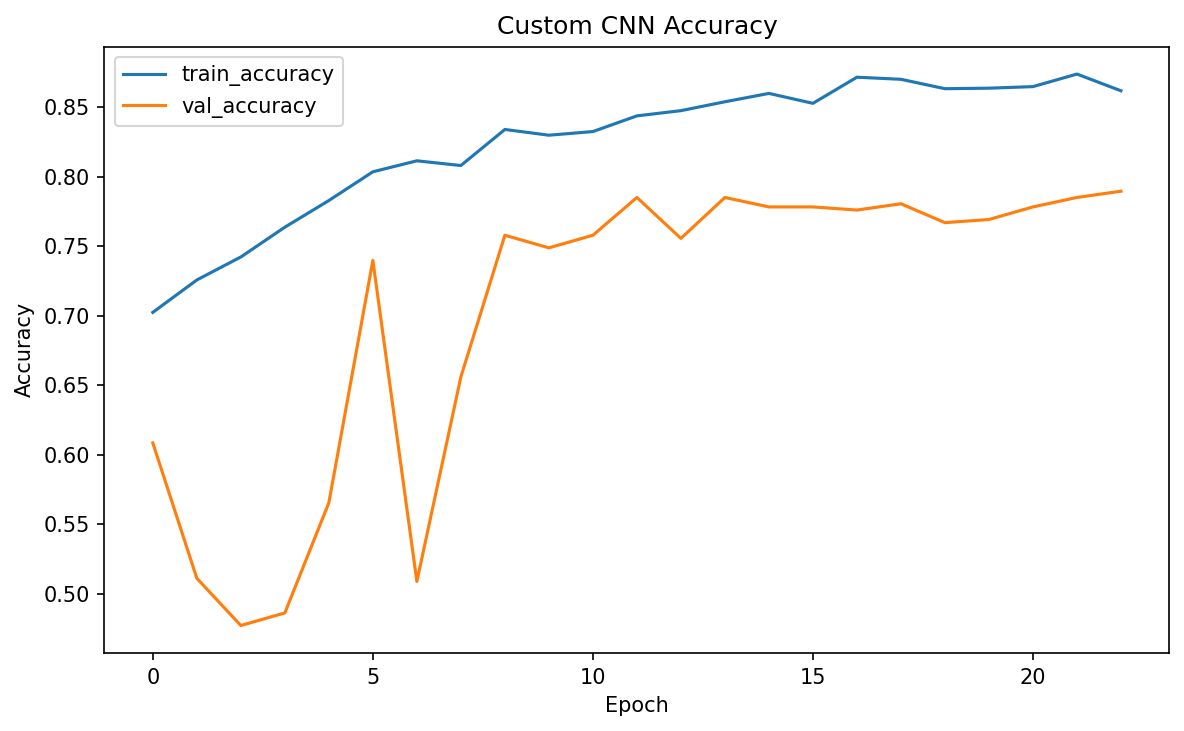

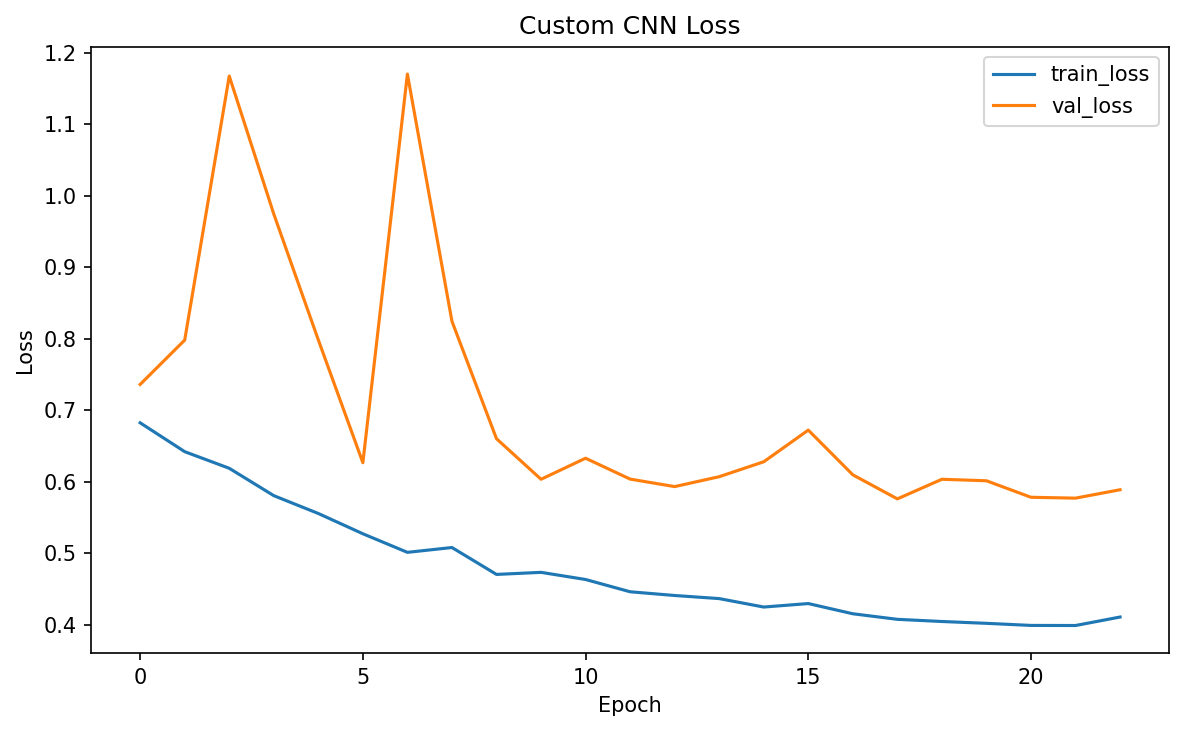

In [24]:
from IPython.display import Image, display

display(Image(filename=str(artifacts["accuracy_curve_path"])))
display(Image(filename=str(artifacts["loss_curve_path"])))

## 9. Review short model notes

This cell reads the generated markdown report so the architecture choice, augmentation choice, and early overfitting/underfitting observations are visible directly in the notebook.

In [25]:
report_text = Path(artifacts["report_path"]).read_text(encoding="utf-8")
print(report_text)

# Custom CNN Report

## Experiment Summary

- Classes: ['bird', 'drone']
- Image size: [224, 224]
- Batch size: 32
- Epochs configured: 25
- Optimizer: adam
- Learning rate: 0.001

## Architecture Choice

A custom CNN was used with 4 convolution blocks, filters [32, 64, 128, 256], batch normalization after each convolutional stage, max pooling for spatial reduction, block-wise dropout [0.1, 0.15, 0.2, 0.25], and a dense head with 128 units and classifier dropout 0.4.

## Augmentation Choice

The training pipeline applied rotation=0.08, horizontal_flip=True, vertical_flip=False, zoom_factor=0.1, brightness_factor=0.15, translation_height_factor=0.08, translation_width_factor=0.08. These choices aim to improve robustness to pose variation, mirroring, small viewpoint changes, illumination changes, and mild spatial shifts.

## Early Observations

The training curves look reasonably stable without strong immediate evidence of severe overfitting or underfitting.

## Validation Metrics

- Acc

## 10. Conclusion

At this stage, the custom CNN branch is complete:
- augmentation pipeline built and preview saved
- model trained on train set and validated on valid set
- best and final models saved
- history and metrics stored
- learning curves exported
- short model notes written to report